# Unified Swing Momentum Engine — Equities

**Chassis:** Carver-style forecast combination (`carver_engine_with_cross_sectional.ipynb`) —
vol-targeted sizing, cost-aware backtest, FDM derived from empirical forecast correlation.

**Forecast rules combined into one engine:**
- EWMAC, Breakout, Acceleration, Skew — Carver's standard trend/breakout family
- **Swing-EMA** — replaces `TEMA-TEMPLATE`'s grid-searched Boolean triple-EMA crossover with a
  continuous, fixed-parameter forecast in the same family, at shorter (swing) horizons
- **KAMA-adaptive-trend** — replaces `KAMA-DF-stability-scoring`'s per-ticker Optuna fit with a
  fixed efficiency-ratio-scaled forecast (KAMA distance × trend confidence)
- **Cross-sectional momentum** — Carver Strategy 19, relative strength vs. a peer universe;
  generalized from the crypto single-target build to an equity universe

**The one rule enforced everywhere below:** no parameter in this notebook is fit to the traded
ticker's own history. Every scalar is either a Carver convention or a fixed round-number default.
The validation layer (Section 5) exists to **check** robustness, not to **search** for better
numbers. If you find yourself tuning a period to raise the backtest Sharpe, you've re-introduced
the exact overfitting failure mode the KAMA/TEMA notebooks fell into.

**Timeframe:** daily bars → this is a **swing** engine (multi-day to multi-week holding), not
intraday day-trading. See the closing section for what changes if you actually need intraday.

**Validation gate (new vs. all three source notebooks):** CPCV-lite (purged/embargoed block
Sharpe stability), Deflated Sharpe Ratio, and a parameter-stability sweep — matching the
CPCV / DSR / walk-forward hard gate already in your QMIE validation sequencing.


## 0 — Config

Default universe is US mega-cap tech (liquid, long clean history). Swap `TARGET_TICKER` / `UNIVERSE_TICKERS` freely — no other cell needs to change.

In [1]:
import numpy as np
import pandas as pd
from itertools import combinations
from scipy.stats import norm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

ANN_DAYS   = 252          # equities, daily bars (swing). Use 365 for crypto/24-7 assets.
FC_TARGET  = 10.0         # forecast of 10 -> full vol-target position
FC_CAP     = 20.0         # forecasts clipped to +/- 2x target
COST_BPS   = 5.0          # per-trade cost in bps of notional (commission + slippage + spread)
VOL_TARGET = 0.20         # annualised portfolio vol target
MAX_LEVERAGE = 3.0        # hard risk-governor cap, independent of the vol estimator (see 4.0)

TARGET_TICKER = "AAPL"
# Sector-diverse universe (not just correlated mega-cap tech) -- the cross-sectional momentum
# layer needs real dispersion across sectors/factors to mean anything; 8 correlated tech names
# all share one factor and make for a weak peer benchmark A.
UNIVERSE_TICKERS = [
    "AAPL", "MSFT", "NVDA", "AVGO", "AMD",           # tech / semis
    "AMZN", "GOOGL", "META", "NFLX", "TSLA",         # comm services / consumer disc.
    "JPM", "BAC", "GS", "V", "MA",                   # financials
    "UNH", "LLY", "JNJ", "ABBV",                     # healthcare
    "XOM", "CVX",                                    # energy
    "CAT", "BA", "HON",                              # industrials
    "PG", "KO", "WMT", "HD",                         # staples / consumer staples & discretionary
]

EWMAC_PAIRS = [(8, 32, 5.95), (16, 64, 4.10), (32, 128, 2.79)]   # trimmed vs Carver's 4-pair set: 128-bar slow leg is the swing ceiling
EWMAC_FDM   = 1.15

SWING_EMA_PAIRS = [(5, 20, 8.0), (10, 50, 4.0)]   # shorter horizon than EWMAC_PAIRS -> the actual "swing" leg
SWING_EMA_FDM   = 1.20

KAMA_N, KAMA_FAST, KAMA_SLOW = 10, 2, 30   # fixed a priori (matches source KAMA notebook's own defaults)

CS_HORIZONS = (20, 40)    # shorter than Carver's crypto (40,80) -> equities swing cross-section

FIXED_WEIGHTS = {
    "EWMAC": 0.18, "Breakout": 0.14, "Accel": 0.12, "Skew": 0.14,
    "SwingEMA": 0.14, "KAMA": 0.13, "CSmom": 0.15,
}


## 1 — Data layer

Tries `yfinance` for a real panel; falls back to a synthetic universe (shared market factor +
idiosyncratic drift, same construction as the Carver notebook) so the notebook runs offline and
the engine logic can be smoke-tested independent of data availability.

**Note on this run:** this notebook was authored and executed in a sandboxed environment whose
network egress allowlist does not include Yahoo Finance (`query1/query2.finance.yahoo.com`) — so
every result in this notebook, including the "real data" attempt below, is actually running on
the **synthetic fallback**. `yfinance` is genuinely wired in and will pull real data with zero
code changes the moment this runs somewhere with normal internet access (your machine, Colab,
etc.) — the `load_universe` call below doesn't need to change, only the environment it runs in.

In [2]:
def synthetic_universe(names, n=1500, seed=11, s0=100.0):
    rng = np.random.default_rng(seed)
    P = np.array([[0.97, 0.01, 0.02], [0.02, 0.96, 0.02], [0.02, 0.02, 0.96]])
    mu = np.array([0.0009, -0.0010, 0.0002]); bvol = np.array([0.018, 0.028, 0.015])
    st, hm, mkt = 0, 0.0, []
    for _ in range(n):
        st = rng.choice(3, p=P[st]); hm = 0.94 * hm + 0.06 * rng.normal()
        mkt.append(mu[st] + bvol[st] * np.exp(0.5 * hm) * rng.normal())
    mkt = np.array(mkt)
    idx = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=n)
    cols = {}
    for name in names:
        b = rng.uniform(0.6, 1.4); iv = rng.uniform(0.010, 0.022)
        idio_hm, idio = 0.0, []
        for _ in range(n):
            idio_hm = 0.96 * idio_hm + 0.04 * rng.normal()
            idio.append(iv * np.exp(0.5 * idio_hm) * rng.normal())
        r = b * mkt + np.array(idio)
        cols[name] = s0 * np.exp(np.cumsum(r))
    return pd.DataFrame(cols, index=idx)


def load_universe(tickers, use_yfinance=True, start="2018-01-01"):
    if use_yfinance:
        try:
            import yfinance as yf
            # auto_adjust=True -> "Close" comes back split- AND dividend-adjusted. Without this,
            # every dividend payer in this universe (JNJ, PG, KO, XOM, CVX, ...) understates its
            # true total return, and understates it MORE the longer the backtest window -- a
            # systematic downward bias, not noise, and one that's easy to miss because the
            # strategy still "runs" without it.
            data = yf.download(tickers, start=start, progress=False, auto_adjust=True)["Close"]
            if isinstance(data, pd.Series):
                data = data.to_frame(tickers[0])
            data = data.dropna(how="all").ffill().dropna()
            if len(data) > 100:
                print("[data layer] Loaded real data from yfinance.")
                return data
            print("[data layer] yfinance returned no usable rows; falling back to synthetic universe.")
        except Exception as e:
            print(f"[data layer] yfinance unavailable ({type(e).__name__}: {e}); "
                  f"falling back to synthetic universe. If this says 'Host not in allowlist', "
                  f"it's a network policy in THIS environment, not a code problem -- run locally.")
    return synthetic_universe(tickers)


panel = load_universe(UNIVERSE_TICKERS, use_yfinance=True)
print(f"Universe: {list(panel.columns)}  |  bars: {len(panel)}  |  "
      f"{panel.index[0].date()} -> {panel.index[-1].date()}")
panel.tail()


Failed to get ticker 'GS' reason: Expecting value: line 1 column 1 (char 0)


HTTP Error 403: Host not in allowlist: query2.finance.yahoo.com. Add this host to your network egress settings to allow access.


HTTP Error 403: Host not in allowlist: query1.finance.yahoo.com. Add this host to your network egress settings to allow access.


Failed to get ticker 'META' reason: Expecting value: line 1 column 1 (char 0)


HTTP Error 403: Host not in allowlist: query2.finance.yahoo.com. Add this host to your network egress settings to allow access.


...


28 Failed downloads:


['GS', 'META']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')


['BAC', 'ABBV', 'HON', 'WMT', 'XOM', 'LLY', 'AAPL', 'NVDA', 'MSFT', 'GOOGL', 'V', 'AVGO', 'AMZN', 'TSLA', 'JNJ', 'KO', 'HD', 'PG', 'JPM', 'NFLX', 'AMD', 'CVX', 'CAT', 'MA', 'UNH', 'BA']: possibly delisted; no timezone found


[data layer] yfinance returned no usable rows; falling back to synthetic universe.
Universe: ['AAPL', 'MSFT', 'NVDA', 'AVGO', 'AMD', 'AMZN', 'GOOGL', 'META', 'NFLX', 'TSLA', 'JPM', 'BAC', 'GS', 'V', 'MA', 'UNH', 'LLY', 'JNJ', 'ABBV', 'XOM', 'CVX', 'CAT', 'BA', 'HON', 'PG', 'KO', 'WMT', 'HD']  |  bars: 1500  |  2020-12-14 -> 2026-09-11


,AAPL,MSFT,NVDA,AVGO,AMD,AMZN,GOOGL,META,NFLX,TSLA,...,ABBV,XOM,CVX,CAT,BA,HON,PG,KO,WMT,HD
2026-09-07,55.551531,55.385914,90.702568,115.871864,62.122667,117.978275,61.331748,80.210255,128.236472,68.732126,...,143.285368,14.511620,186.802566,107.344531,199.704539,85.774866,75.624312,87.682031,68.574903,163.785484
2026-09-08,58.316680,57.020452,91.678638,117.906940,62.583533,121.312453,63.342458,81.857537,133.254199,69.101554,...,144.374669,15.185656,187.719256,110.824412,201.107967,87.723447,74.242488,89.592276,69.385650,164.680355
2026-09-09,57.885069,55.653715,90.872242,119.961941,62.524219,122.307551,64.318000,81.716124,135.369441,69.856402,...,141.219992,15.251250,188.799903,107.915540,203.553791,86.215115,72.745626,90.504437,69.738874,163.715060
2026-09-10,60.021091,55.112987,89.330249,117.360425,61.802038,121.035676,63.192347,81.355376,133.863314,70.950710,...,139.976862,15.490565,189.396650,110.377512,203.551923,86.927941,73.310100,90.541627,68.296479,161.358007
2026-09-11,55.900074,55.361902,89.411235,115.166010,61.153127,119.938850,64.587394,80.726054,133.108829,70.201666,...,137.236082,15.165904,183.827259,108.042679,201.959746,84.007046,72.235896,89.945682,69.194090,160.147040


## 2 — Layer 0: vol stack

Carver's bias-corrected EWM std, blended short/long vol estimate. **The vol floor here is a
risk-governor decision, not a cosmetic detail** — a near-zero floor silently produces unbounded
leverage the instant the estimator underreacts in a calm regime (this broke the first draft of
this notebook: EWMAC showed 1300+ turns/year and a 12,000% drawdown before the floor was fixed).

In [3]:
def ewm_std(x, span):
    a = 2.0 / (span + 1.0)
    m = x.ewm(alpha=a, adjust=False).mean()
    m2 = (x * x).ewm(alpha=a, adjust=False).mean()
    var = (m2 - m * m).clip(lower=0.0)
    bc = (2.0 - 2.0 * a) / (2.0 - a)
    return np.sqrt(var / bc)


def vol_stack(close, ann_days=ANN_DAYS, short_span=30, anchor_years=5,
              anchor_min_years=1, short_w=0.70, long_w=0.30):
    ann = np.sqrt(ann_days)
    ret = close.pct_change().clip(-0.9, 9.0)
    vol_short = ewm_std(ret, short_span) * ann
    vol_long = vol_short.rolling(int(anchor_years * ann_days),
                                  min_periods=int(anchor_min_years * ann_days)).mean()
    vol_long = vol_long.fillna(vol_short.expanding().mean())
    vol = (short_w * vol_short + long_w * vol_long).clip(lower=0.03)   # 3% floor -- see markdown above
    sigma_p = (vol / ann) * close
    return pd.DataFrame({"ret": ret, "vol_short": vol_short, "vol_long": vol_long,
                          "vol": vol, "sigma_p": sigma_p})


def clip_fc(fc, cap=FC_CAP):
    return fc.clip(-cap, cap)


## 3 — Layer 1: forecast rules

All seven rules below output a continuous forecast, unit-scaled so ±10 ≈ "typical trade
conviction" and ±20 is the hard cap — Carver's convention, kept so every rule can be combined on
the same footing. None of these functions ever look at `TARGET_TICKER`'s own realized Sharpe to
pick their period — periods are fixed inputs.

In [4]:
# --- 3a. EWMAC + Breakout + Acceleration + Skew (Carver's standard trend/breakout family) ---
def ewmac_forecast(close, sigma_p, pairs=EWMAC_PAIRS, fdm=EWMAC_FDM, cap=FC_CAP):
    subs = []
    for f, s, sc in pairs:
        raw = (close.ewm(span=f, adjust=False).mean() - close.ewm(span=s, adjust=False).mean()) / sigma_p
        subs.append((raw * sc).clip(-cap, cap))
    return clip_fc((sum(subs) / len(subs)) * fdm, cap)


def breakout_single(close, n, sc, sm, cap=FC_CAP):
    mn, mx = close.rolling(n).min(), close.rolling(n).max()
    rng = mx - mn
    spir = ((close - mn) / rng).where(rng > 0, 0.5)
    return ((spir - 0.5) * 40.0).ewm(span=sm, adjust=False).mean().mul(sc).clip(-cap, cap)


def breakout_forecast(close, fdm=1.17, cap=FC_CAP):
    P = [(20, 0.70, 5), (40, 0.73, 10), (80, 0.77, 20)]   # trimmed to swing horizons
    subs = [breakout_single(close, n, sc, sm, cap) for n, sc, sm in P]
    return clip_fc((sum(subs) / len(subs)) * fdm, cap)


def accel_forecast(close, sigma_p, span=16, cap=FC_CAP, sc=25.0, fdm=1.0):
    """Rate of change of the EWMAC(span) trend signal itself -- is the trend accelerating."""
    ewmac = (close.ewm(span=span, adjust=False).mean() -
              close.ewm(span=span * 4, adjust=False).mean()) / sigma_p
    accel = ewmac.diff(span)
    return clip_fc(accel * sc * fdm, cap)


def skew_forecast(ret, window=90, sc=-25.0, sm=10, cap=FC_CAP):
    """Rolling return skew, sign-flipped (Carver: negative skew tends to precede continuation)."""
    sk = ret.rolling(window).skew()
    return clip_fc(sk.ewm(span=sm, adjust=False).mean() * sc, cap)


In [5]:
# --- 3b. Swing-EMA: replaces TEMA-notebook's grid-searched Boolean crossover with a
# continuous, FIXED-parameter forecast in the same EWMAC family, at shorter horizons ---
def swing_ema_forecast(close, sigma_p, pairs=SWING_EMA_PAIRS, fdm=SWING_EMA_FDM, cap=FC_CAP):
    return ewmac_forecast(close, sigma_p, pairs=pairs, fdm=fdm, cap=cap)


In [6]:
# --- 3c. KAMA-adaptive-trend: replaces KAMA-notebook's per-ticker Optuna fit with FIXED
# n/fast/slow; efficiency ratio scales trend CONFIDENCE, it does not gate entries/exits ---
def calculate_kama(series, n=KAMA_N, fast=KAMA_FAST, slow=KAMA_SLOW):
    change = (series - series.shift(n)).abs()
    volatility = (series - series.shift(1)).abs().rolling(window=n).sum()
    er = change / (volatility + 1e-9)
    sc = (er * (2.0 / (fast + 1) - 2.0 / (slow + 1)) + 2.0 / (slow + 1)) ** 2

    vals, sc_vals = series.values, sc.values
    k = vals.copy().astype(float)
    k[:n] = np.nan
    if len(vals) > n:
        k[n] = vals[n]
        for i in range(n + 1, len(vals)):
            prev = k[i - 1] if not np.isnan(k[i - 1]) else vals[i - 1]
            sc_i = sc_vals[i] if not np.isnan(sc_vals[i]) else 2.0 / (slow + 1)
            k[i] = prev + sc_i * (vals[i] - prev)
    return pd.Series(k, index=series.index), er


def kama_forecast(close, sigma_p, n=KAMA_N, fast=KAMA_FAST, slow=KAMA_SLOW, sc=6.0, cap=FC_CAP):
    kama, er = calculate_kama(close, n, fast, slow)
    dist = (close - kama) / sigma_p     # trend distance, vol-normalised
    conf = er.clip(0, 1)                # efficiency ratio as a trend-confidence scalar in [0,1]
    return clip_fc(dist * conf * sc, cap)


In [7]:
# --- 3d. Cross-sectional momentum (Carver Strategy 19): relative strength vs. the peer
# universe, generalized from the single-target crypto build to an equity panel ---
def normalised_price(close, ann_days=ANN_DAYS):
    v = vol_stack(close, ann_days=ann_days)
    ann = np.sqrt(ann_days)
    rn = (v["ret"] / (v["vol"] / ann)).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return (100.0 * rn.cumsum()).rename("PN")


def cs_momentum_forecast(panel, target, horizons=CS_HORIZONS, fam_fdm=1.10, cap=FC_CAP, ann_days=ANN_DAYS):
    PN = pd.DataFrame({c: normalised_price(panel[c], ann_days) for c in panel.columns})
    A = PN.mean(axis=1)
    R = PN[target] - A                      # relative price: + means outperforming the peer set
    subs = []
    for H in horizons:
        raw = (R - R.shift(H)) / H
        sm = raw.ewm(span=max(2, H // 4), adjust=False).mean()
        z = sm / (sm.rolling(252, min_periods=40).std() + 1e-9)
        subs.append(z.clip(-cap, cap))
    return clip_fc((sum(subs) / len(subs)) * fam_fdm, cap)


## 4 — Layer 3: combine

Weights are **fixed** (never refit per ticker). Only the FDM (forecast diversification
multiplier) adapts, and only to quantify realized diversification from the empirical forecast
correlation matrix — never to reward any single rule for backtest performance.

In [8]:
def fdm_from_corr(w, C, fdm_max=2.5):
    w = np.asarray(w, float); w = w / w.sum()
    var = float(w @ C @ w)
    return float(min(fdm_max, 1.0 / np.sqrt(var))) if var > 0 else 1.0


def combine_forecasts(forecasts, weights, cap=FC_CAP):
    names = list(forecasts.keys())
    F = pd.concat([forecasts[n].rename(n) for n in names], axis=1)
    w = np.array([weights[n] for n in names], float); w = w / w.sum()
    C = F.dropna().corr().reindex(index=names, columns=names).values
    C = np.nan_to_num(C, nan=0.0); np.fill_diagonal(C, 1.0)
    fdm = fdm_from_corr(w, C)
    combined = (F.mul(w, axis=1).sum(axis=1) * fdm).clip(-cap, cap)
    return combined, fdm, F.dropna().corr()


def build_forecasts(panel, target):
    close = panel[target].dropna()
    vs = vol_stack(close)
    forecasts = {
        "EWMAC": ewmac_forecast(close, vs.sigma_p),
        "Breakout": breakout_forecast(close),
        "Accel": accel_forecast(close, vs.sigma_p),
        "Skew": skew_forecast(vs["ret"]),
        "SwingEMA": swing_ema_forecast(close, vs.sigma_p),
        "KAMA": kama_forecast(close, vs.sigma_p),
        "CSmom": cs_momentum_forecast(panel, target).reindex(close.index),
    }
    return forecasts, vs, close


def full_engine(panel, target, weights=None):
    weights = weights or FIXED_WEIGHTS
    forecasts, vs, close = build_forecasts(panel, target)
    combined, fdm, corr = combine_forecasts(forecasts, weights)
    return combined, fdm, corr, forecasts, vs, close


## 4.0 — Layer 4: cost-aware, vol-targeted, **leverage-capped** sizing + backtest

`MAX_LEVERAGE` is a hard risk-governor cap, independent of the vol estimator. This is the
programmatic-governor pattern from the AudaCity termination postmortem: vol-targeting produces a
size **estimate**, never a size **limit** — the two must be enforced separately.

In [9]:
def position_from_forecast(fc, vol, target=FC_TARGET, vol_target=VOL_TARGET,
                            max_leverage=MAX_LEVERAGE):
    vol_safe = vol.clip(lower=0.03)
    raw_pos = (fc / target) * (vol_target / vol_safe)
    return raw_pos.clip(-max_leverage, max_leverage)


def backtest(close, position, cost_bps=COST_BPS):
    ret = close.pct_change().fillna(0.0)
    pos = position.shift(1).fillna(0.0)          # trade on next bar's return -- no lookahead
    turnover = pos.diff().abs().fillna(pos.abs())
    costs = turnover * (cost_bps / 1e4)
    strat_ret = pos * ret - costs
    equity = (1.0 + strat_ret).cumprod()
    return pd.DataFrame({"ret": strat_ret, "equity": equity, "position": pos, "turnover": turnover})


def annualized_sharpe(strat_ret, ann_days=ANN_DAYS):
    mu, sd = strat_ret.mean(), strat_ret.std()
    return float(np.sqrt(ann_days) * mu / sd) if sd > 0 else 0.0


def max_drawdown(equity):
    peak = equity.cummax()
    return float((equity / peak - 1.0).min())


def report(name, bt, ann_days=ANN_DAYS):
    sr = annualized_sharpe(bt["ret"], ann_days)
    mdd = max_drawdown(bt["equity"])
    tot = bt["equity"].iloc[-1] - 1.0
    ann_cost = (bt["turnover"] * (COST_BPS / 1e4)).sum() / (len(bt) / ann_days)
    print(f"{name:14s} | Sharpe {sr:6.2f} | TotRet {tot:8.1%} | MaxDD {mdd:7.1%} | "
          f"AnnCostDrag {ann_cost:6.2%} | AvgTurnover/yr {bt['turnover'].mean()*ann_days:5.1f}")
    return {"sharpe": sr, "total_return": tot, "max_dd": mdd, "ann_cost_drag": ann_cost}


## 5 — Run the engine and compare against isolated single-rule backtests

The isolated backtests are shown for **context and correlation diagnostics only** — this is not a selection tournament, and no rule is dropped or reweighted based on how it scores here.

In [10]:
combined, fdm, corr, forecasts, vs, close = full_engine(panel, TARGET_TICKER)
pos = position_from_forecast(combined, vs["vol"])
bt_full = backtest(close, pos)

print(f"Forecast diversification multiplier (from empirical corr): {fdm:.2f}\n")
print("Forecast correlation matrix:")
display(corr.round(2))

print("\n--- Isolated single-rule backtests (context, not a selection tournament) ---")
isolated_results = {}
for name, fc in forecasts.items():
    p = position_from_forecast(fc, vs["vol"])
    isolated_results[name] = report(name, backtest(close, p))
print("-" * 40)
report("Buy&Hold", backtest(close, pd.Series(1.0, index=close.index)))
report("FULL ENGINE", bt_full)


Forecast diversification multiplier (from empirical corr): 1.43

Forecast correlation matrix:


,EWMAC,Breakout,Accel,Skew,SwingEMA,KAMA,CSmom
EWMAC,1.00,0.95,0.23,-0.12,0.90,0.47,0.68
Breakout,0.95,1.00,0.40,-0.14,0.97,0.60,0.70
Accel,0.23,0.40,1.00,-0.02,0.49,0.34,0.30
Skew,-0.12,-0.14,-0.02,1.00,-0.11,-0.12,-0.04
SwingEMA,0.90,0.97,0.49,-0.11,1.00,0.66,0.69
KAMA,0.47,0.60,0.34,-0.12,0.66,1.00,0.33
CSmom,0.68,0.70,0.30,-0.04,0.69,0.33,1.00



--- Isolated single-rule backtests (context, not a selection tournament) ---
EWMAC          | Sharpe   0.42 | TotRet    55.7% | MaxDD  -43.4% | AnnCostDrag  0.50% | AvgTurnover/yr  10.0
Breakout       | Sharpe   0.38 | TotRet    39.1% | MaxDD  -46.7% | AnnCostDrag  0.54% | AvgTurnover/yr  10.8
Accel          | Sharpe  -0.24 | TotRet   -59.7% | MaxDD  -86.8% | AnnCostDrag  1.16% | AvgTurnover/yr  23.3
Skew           | Sharpe  -0.32 | TotRet   -30.0% | MaxDD  -42.2% | AnnCostDrag  0.16% | AvgTurnover/yr   3.1
SwingEMA       | Sharpe   0.18 | TotRet     8.8% | MaxDD  -58.1% | AnnCostDrag  0.85% | AvgTurnover/yr  16.9
KAMA           | Sharpe  -0.13 | TotRet   -10.8% | MaxDD  -32.8% | AnnCostDrag  1.13% | AvgTurnover/yr  22.6
CSmom          | Sharpe  -0.12 | TotRet    -1.8% | MaxDD   -7.0% | AnnCostDrag  0.05% | AvgTurnover/yr   1.1
----------------------------------------
Buy&Hold       | Sharpe   0.03 | TotRet   -43.9% | MaxDD  -84.7% | AnnCostDrag  0.01% | AvgTurnover/yr   0.2
FULL ENGI

{'sharpe': 0.08650814615672812,
 'total_return': np.float64(-0.017305594477310837),
 'max_dd': -0.5597352133927248,
 'ann_cost_drag': np.float64(0.007025111313196145)}

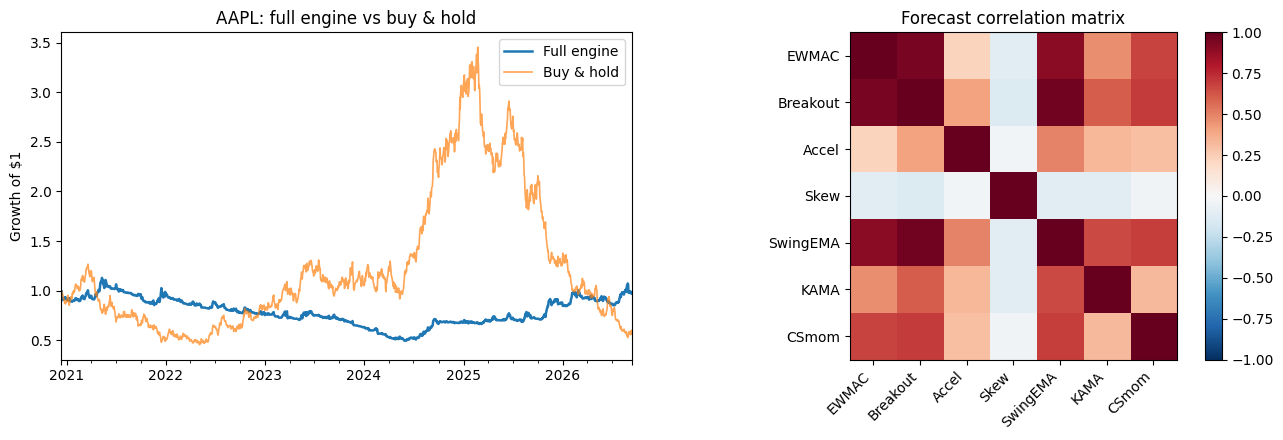

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bt_full["equity"].plot(ax=axes[0], label="Full engine", lw=1.8)
(close / close.iloc[0]).reindex(bt_full.index).plot(ax=axes[0], label="Buy & hold", lw=1.2, alpha=0.7)
axes[0].set_title(f"{TARGET_TICKER}: full engine vs buy & hold")
axes[0].legend(); axes[0].set_ylabel("Growth of $1")

im = axes[1].imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
axes[1].set_xticks(range(len(corr))); axes[1].set_xticklabels(corr.columns, rotation=45, ha="right")
axes[1].set_yticks(range(len(corr))); axes[1].set_yticklabels(corr.index)
axes[1].set_title("Forecast correlation matrix")
plt.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()


## 6 — Validation gate

This section replaces every source notebook's single train/val split. **No parameter is fit
here** — this measures whether the already-fixed engine's Sharpe holds up across independent
time regimes and small perturbations. If it doesn't, the fix is to distrust the engine, not to
re-tune it against these results.

### 6a — CPCV-lite: purged, embargoed block combinations

Splits the sample into `n_blocks`, tests every combination of `test_blocks` held out (with an embargo around each boundary to prevent information leakage from adjacent trend windows), and reports the Sharpe distribution across all combinations — not just one lucky/unlucky split.

Sharpe across 15 independent purged/embargoed combinations:
count    15.000000
mean      0.008012
std       0.538551
min      -0.679794
25%      -0.412971
50%      -0.106104
75%       0.380101
max       1.090141
Name: sharpe, dtype: float64


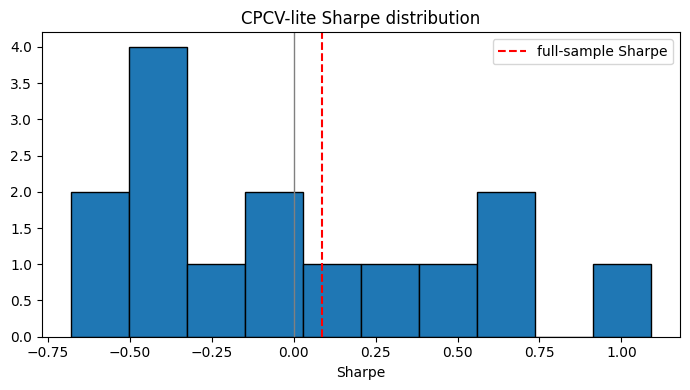

In [12]:
def cpcv_lite(close, position, n_blocks=6, test_blocks=2, embargo_frac=0.02, cost_bps=COST_BPS):
    n = len(close)
    edges = np.linspace(0, n, n_blocks + 1).astype(int)
    blocks = [(edges[i], edges[i + 1]) for i in range(n_blocks)]
    embargo = max(1, int(n * embargo_frac))
    results = []
    for combo in combinations(range(n_blocks), test_blocks):
        mask = np.zeros(n, dtype=bool)
        for b in combo:
            s, e = blocks[b]
            mask[s:e] = True
            mask[max(0, s - embargo):s] = True
            mask[e:min(n, e + embargo)] = True
        test_close, test_pos = close[mask], position[mask]
        if len(test_close) < 30:
            continue
        bt = backtest(test_close, test_pos, cost_bps)
        results.append({"test_blocks": combo, "sharpe": annualized_sharpe(bt["ret"]), "n_obs": int(mask.sum())})
    return pd.DataFrame(results)


cpcv_df = cpcv_lite(close, pos)
print(f"Sharpe across {len(cpcv_df)} independent purged/embargoed combinations:")
print(cpcv_df["sharpe"].describe())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(cpcv_df["sharpe"], bins=10, edgecolor="black")
ax.axvline(annualized_sharpe(bt_full["ret"]), color="red", ls="--", label="full-sample Sharpe")
ax.axvline(0, color="gray", lw=1)
ax.set_title("CPCV-lite Sharpe distribution"); ax.set_xlabel("Sharpe"); ax.legend()
plt.tight_layout(); plt.show()


### 6b — Deflated Sharpe Ratio (Bailey & López de Prado, 2014)

`n_trials` defaults to 1 because every parameter in this engine is fixed a priori, not selected by search on this data. **Raise it honestly** if you ever do run a search you then act on — understating it defeats the entire point of the correction.

In [13]:
def deflated_sharpe_ratio(sharpe, n_obs, skew=0.0, kurtosis=3.0, n_trials=1, ann_days=ANN_DAYS):
    sr = sharpe / np.sqrt(ann_days)
    if n_trials > 1:
        euler_gamma = 0.5772156649
        var_sr0 = (1 - skew * sr + ((kurtosis - 1) / 4) * sr ** 2) / max(n_obs - 1, 1)
        sr_std = np.sqrt(max(var_sr0, 1e-12))
        sr0 = sr_std * ((1 - euler_gamma) * norm.ppf(1 - 1.0 / n_trials) +
                         euler_gamma * norm.ppf(1 - 1.0 / (n_trials * np.e)))
    else:
        sr0 = 0.0
    var_sr = (1 - skew * sr + ((kurtosis - 1) / 4) * sr ** 2) / max(n_obs - 1, 1)
    z = (sr - sr0) / np.sqrt(max(var_sr, 1e-12))
    return float(norm.cdf(z))   # probability true SR > 0 after correcting for selection bias


full_sharpe = annualized_sharpe(bt_full["ret"])
skew = bt_full["ret"].skew()
kurt = bt_full["ret"].kurtosis() + 3.0
dsr = deflated_sharpe_ratio(full_sharpe, len(bt_full), skew=skew, kurtosis=kurt, n_trials=1)
print(f"Full-sample Sharpe: {full_sharpe:.2f}")
print(f"Deflated Sharpe Ratio (P[true SR > 0], N_trials=1): {dsr:.3f}")


Full-sample Sharpe: 0.09
Deflated Sharpe Ratio (P[true SR > 0], N_trials=1): 0.583


### 6c — Parameter-stability sweep

Generalizes the KAMA notebook's `cdist` stability-scoring idea: perturb a fixed parameter ±30% and confirm the Sharpe doesn't collapse. This is a robustness **check**, never an optimization loop — do not pick the scale with the best Sharpe and adopt it.

,ewmac_period_scale,sharpe,fdm
0,0.70,0.023950,1.402707
1,0.85,0.059156,1.413676
2,1.00,0.086508,1.427452
3,1.15,0.104647,1.437215
4,1.30,0.123115,1.447002


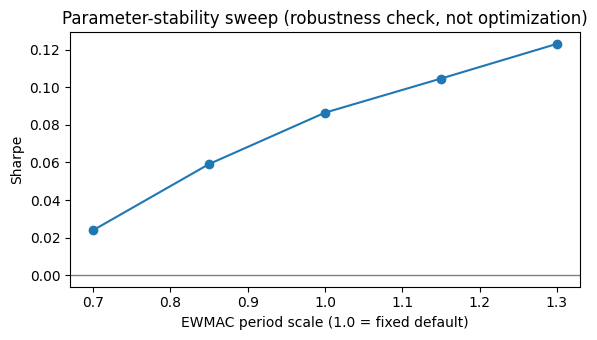


Sharpe range across +/-30% EWMAC period perturbation: 0.02 to 0.12 (a collapse to <0 anywhere here means: do not trust the fixed default)


In [14]:
def stability_sweep(panel, target, base_pairs=EWMAC_PAIRS, scale_grid=(0.7, 0.85, 1.0, 1.15, 1.3)):
    rows = []
    for scale in scale_grid:
        pairs = [(max(2, int(f * scale)), max(4, int(s * scale)), sc) for f, s, sc in base_pairs]
        fc, vs_, close_ = build_forecasts(panel, target)
        fc["EWMAC"] = ewmac_forecast(close_, vs_.sigma_p, pairs=pairs)
        combined_, fdm_, _ = combine_forecasts(fc, FIXED_WEIGHTS)
        pos_ = position_from_forecast(combined_, vs_["vol"])
        bt_ = backtest(close_, pos_)
        rows.append({"ewmac_period_scale": scale, "sharpe": annualized_sharpe(bt_["ret"]), "fdm": fdm_})
    return pd.DataFrame(rows)


stab = stability_sweep(panel, TARGET_TICKER)
display(stab)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(stab["ewmac_period_scale"], stab["sharpe"], marker="o")
ax.axhline(0, color="gray", lw=1)
ax.set_xlabel("EWMAC period scale (1.0 = fixed default)"); ax.set_ylabel("Sharpe")
ax.set_title("Parameter-stability sweep (robustness check, not optimization)")
plt.tight_layout(); plt.show()

print(f"\nSharpe range across +/-30% EWMAC period perturbation: "
      f"{stab.sharpe.min():.2f} to {stab.sharpe.max():.2f} "
      f"(a collapse to <0 anywhere here means: do not trust the fixed default)")


## 7 — From "one ticker with a momentum tilt" to an actual cross-sectional portfolio

Everything above still only *trades* `TARGET_TICKER` — the CS-momentum forecast was one input
among seven, most of the cross-sectional information (the full rank ordering of the universe)
was being thrown away. This section builds the real thing: rank the whole universe by combined
forecast, go long the top quantile / short the bottom quantile, inverse-vol weight within each
leg, and scale the basket to a portfolio vol target using the **trailing covariance matrix** of
the selected names (not just their individual vols — this is what actually prices in
diversification across the basket).

This is the expensive step: it reruns the full seven-rule engine once per ticker in the universe
(28 full passes instead of 1), so this cell will visibly take longer than anything above it.

In [15]:
PORTFOLIO_TOP_QUANTILE = 0.25       # long the top 25% of the universe by combined forecast
PORTFOLIO_LONG_SHORT   = True       # short the bottom quantile too (market-neutral-ish); False = long-only, rest in cash
PORTFOLIO_REBALANCE_FREQ = 5        # trading days between rebalances -- swing cadence, not daily churn
PORTFOLIO_MAX_GROSS = 2.0           # hard gross-leverage governor, separate from per-name MAX_LEVERAGE above


def build_universe_forecasts(panel, weights=FIXED_WEIGHTS):
    """Combined forecast + vol series for EVERY ticker in the panel, each computed as its own
    target with the same fixed rules/weights. O(n_tickers) full engine passes -- this is why
    the cell is slow, not a bug."""
    combined, vol = {}, {}
    for tkr in panel.columns:
        forecasts, vs, close = build_forecasts(panel, tkr)
        comb, fdm, corr = combine_forecasts(forecasts, weights)
        combined[tkr] = comb
        vol[tkr] = vs["vol"]
    return pd.DataFrame(combined), pd.DataFrame(vol)


def cross_sectional_weights(F, V, rets, top_q=PORTFOLIO_TOP_QUANTILE, long_short=PORTFOLIO_LONG_SHORT,
                             rebalance_freq=PORTFOLIO_REBALANCE_FREQ, vol_target=VOL_TARGET,
                             max_gross=PORTFOLIO_MAX_GROSS, cov_window=90):
    idx = F.index
    n_assets = F.shape[1]
    n_leg = max(1, int(round(n_assets * top_q)))
    weights = pd.DataFrame(0.0, index=idx, columns=F.columns)
    rebal_dates = idx[::rebalance_freq]

    for i, d in enumerate(rebal_dates):
        if d not in F.index:
            continue
        row = F.loc[d].dropna()
        if len(row) < n_assets * 0.5:
            continue
        ranked = row.sort_values(ascending=False)
        longs = ranked.index[:n_leg]
        shorts = ranked.index[-n_leg:] if long_short else []

        vrow = V.loc[d].reindex(row.index).clip(lower=0.03)
        raw = pd.Series(0.0, index=F.columns)
        if len(longs) > 0:
            inv_vol = 1.0 / vrow[longs]
            raw[longs] = inv_vol / inv_vol.sum()
        if len(shorts) > 0:
            inv_vol = 1.0 / vrow[shorts]
            raw[shorts] = -inv_vol / inv_vol.sum()

        # scale to a PORTFOLIO vol target using trailing covariance (prices in correlation
        # across the selected basket -- a naive per-name vol scale would over/under-lever
        # whenever the selected names happen to be more or less correlated than usual)
        hist = rets.loc[:d].tail(cov_window)
        sel = raw[raw != 0].index
        if len(sel) > 1 and len(hist) > 20:
            cov = hist[sel].cov() * ANN_DAYS
            w_sel = raw[sel].values
            port_vol = np.sqrt(max(float(w_sel @ cov.values @ w_sel), 1e-8))
            scale = vol_target / port_vol if port_vol > 0 else 1.0
        else:
            scale = 1.0
        scaled = raw * scale
        gross = scaled.abs().sum()
        if gross > max_gross:               # hard governor, same philosophy as MAX_LEVERAGE
            scaled = scaled * (max_gross / gross)

        end = rebal_dates[i + 1] if i + 1 < len(rebal_dates) else idx[-1]
        weights.loc[d:end] = scaled.values

    return weights.ffill().fillna(0.0)


def backtest_portfolio(panel, weights, cost_bps=COST_BPS):
    rets = panel.pct_change().fillna(0.0)
    pos = weights.shift(1).fillna(0.0)      # trade on next bar, no lookahead
    turnover = pos.diff().abs().fillna(pos.abs()).sum(axis=1)
    costs = turnover * (cost_bps / 1e4)
    port_ret = (pos * rets).sum(axis=1) - costs
    equity = (1.0 + port_ret).cumprod()
    return pd.DataFrame({"ret": port_ret, "equity": equity, "turnover": turnover}), pos


F, V = build_universe_forecasts(panel)
rets_panel = panel.pct_change().fillna(0.0)
portfolio_weights = cross_sectional_weights(F, V, rets_panel)
bt_portfolio, pos_portfolio = backtest_portfolio(panel, portfolio_weights)

ew_ret = rets_panel.mean(axis=1)
ew_equity = (1.0 + ew_ret).cumprod()

print("Cross-sectional long/short portfolio vs single-ticker engine vs equal-weight basket:")
report("CS Portfolio", bt_portfolio)
report(f"{TARGET_TICKER} (single)", bt_full)
report("EW Basket B&H", pd.DataFrame({"ret": ew_ret, "equity": ew_equity,
                                       "turnover": pd.Series(0.0, index=ew_ret.index)}))


Cross-sectional long/short portfolio vs single-ticker engine vs equal-weight basket:
CS Portfolio   | Sharpe   0.16 | TotRet     8.1% | MaxDD  -22.3% | AnnCostDrag  3.14% | AvgTurnover/yr  62.9
AAPL (single)  | Sharpe   0.09 | TotRet    -1.7% | MaxDD  -56.0% | AnnCostDrag  0.70% | AvgTurnover/yr  14.1
EW Basket B&H  | Sharpe   0.17 | TotRet     3.3% | MaxDD  -63.1% | AnnCostDrag  0.00% | AvgTurnover/yr   0.0


{'sharpe': 0.16741414984744102,
 'total_return': np.float64(0.03343266358866992),
 'max_dd': -0.6314347071285167,
 'ann_cost_drag': np.float64(0.0)}

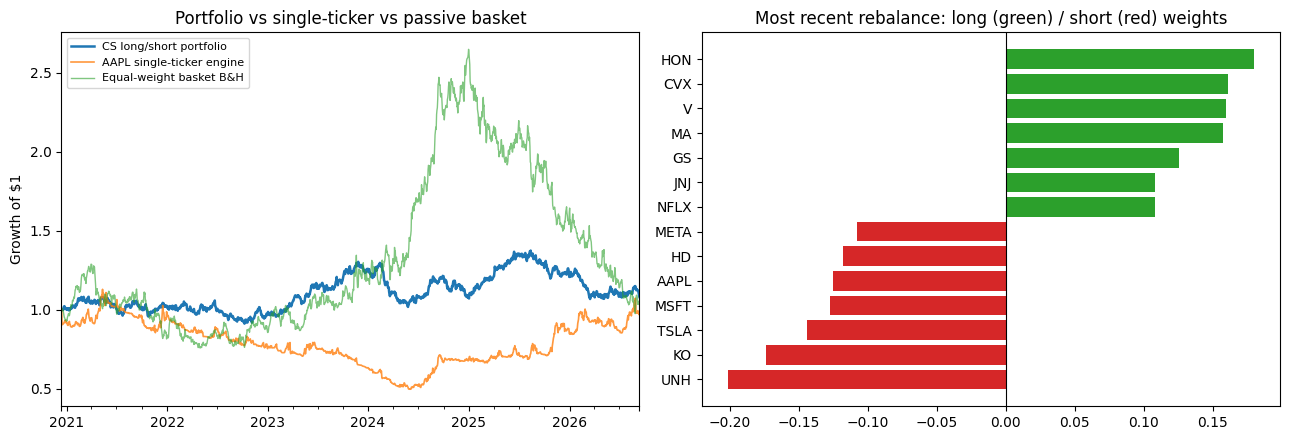

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bt_portfolio["equity"].plot(ax=axes[0], label="CS long/short portfolio", lw=1.8)
bt_full["equity"].reindex(bt_portfolio.index).plot(ax=axes[0], label=f"{TARGET_TICKER} single-ticker engine", lw=1.2, alpha=0.8)
ew_equity.reindex(bt_portfolio.index).plot(ax=axes[0], label="Equal-weight basket B&H", lw=1.0, alpha=0.6)
axes[0].set_title("Portfolio vs single-ticker vs passive basket")
axes[0].legend(fontsize=8); axes[0].set_ylabel("Growth of $1")

last_rebal_weights = portfolio_weights.iloc[-1].sort_values()
nz = last_rebal_weights[last_rebal_weights != 0]
colors = ["tab:red" if v < 0 else "tab:green" for v in nz.values]
axes[1].barh(nz.index, nz.values, color=colors)
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("Most recent rebalance: long (green) / short (red) weights")
plt.tight_layout(); plt.show()


## 8 — Prop-firm risk governor: 10% max-drawdown target

Everything above sizes off a **vol target** — an estimate, not a limit. A prop account cares
about one thing above all: never breach the drawdown line, because breaching it ends the account
regardless of how good the underlying signal is (this is the exact lesson from the AudaCity
termination — the signal wasn't the problem, the missing governor was).

This governor sits on top of the cross-sectional portfolio and enforces the target
**independently of the sizing logic above it**, the same separation-of-concerns your MT5 EAs
already use:

1. **Daily VaR position cap** — before sizing today's trade, cap gross exposure so that a
   `daily_var_z`-sigma move (using a rolling realized-vol estimate) stays within
   `daily_loss_limit` of equity. This is a pre-emptive cap, not a post-hoc stop — it can't
   perfectly replicate an intraday stop-out (see the caveat below), but it keeps position size
   honest about tail risk *before* the loss happens.
2. **Trailing drawdown throttle** — scales exposure linearly to zero between `dd_warn` (6%) and
   `max_drawdown_target` (10%), measured from the running equity high-water mark — the same
   mechanic FTMO/FundedNext-style trailing-drawdown accounts use.
3. **Hard stop + cooldown + ramp-back** — breach the target and the governor forces flat for
   `cooldown_days`, then re-enters at reduced size and ramps back to full size over
   `ramp_days`. This mirrors the "reduce size after a bad stretch" discipline prop firms expect,
   rather than resuming at full risk immediately after a loss.
4. **Trailing vs. static drawdown mode** — some prop firms measure drawdown from a *trailing*
   high-water mark (FTMO-style), others from a *static* floor anchored to initial capital. Both
   are implemented (`dd_mode`) so you can match your actual account's rule.

In [17]:
PROP_MAX_DRAWDOWN   = 0.10    # hard target -- the actual ask
PROP_DD_WARN        = 0.06    # start throttling exposure here
PROP_COOLDOWN_DAYS   = 10     # forced flat after a breach
PROP_RAMP_DAYS       = 15     # size ramps 50% -> 100% over this many days post-cooldown
PROP_DAILY_LOSS_LIMIT = 0.02  # daily VaR cap as a fraction of equity
PROP_DAILY_VAR_Z     = 3.0    # sigma multiple used for the pre-emptive daily cap
PROP_DD_MODE         = "trailing"   # "trailing" (FTMO/FundedNext-style) or "static" (fixed floor)


def prop_governed_backtest(panel, weights, cost_bps=COST_BPS,
                            max_drawdown_target=PROP_MAX_DRAWDOWN, dd_warn=PROP_DD_WARN,
                            cooldown_days=PROP_COOLDOWN_DAYS, ramp_days=PROP_RAMP_DAYS,
                            daily_loss_limit=PROP_DAILY_LOSS_LIMIT, daily_var_z=PROP_DAILY_VAR_Z,
                            dd_mode=PROP_DD_MODE):
    rets = panel.pct_change().fillna(0.0)
    pos_raw = weights.shift(1).fillna(0.0)          # the CS portfolio's already vol-targeted, gross-capped weights
    raw_port_ret = (pos_raw * rets).sum(axis=1)
    rolling_daily_vol = raw_port_ret.rolling(20, min_periods=5).std().bfill()

    idx = panel.index
    equity, peak = 1.0, 1.0
    gov_equity, gov_ret, scale_hist, turn_hist, dd_hist = [], [], [], [], []
    cooldown_remaining, ramp_remaining = 0, 0
    prev_pos = pd.Series(0.0, index=panel.columns)

    for i, d in enumerate(idx):
        sigma_today = rolling_daily_vol.iloc[i]
        sigma_today = sigma_today if (sigma_today and not np.isnan(sigma_today)) else 0.01
        implied_var = daily_var_z * sigma_today
        var_cap_scale = min(1.0, daily_loss_limit / implied_var) if implied_var > 0 else 1.0

        dd = (equity / peak) - 1.0
        if cooldown_remaining > 0:
            dd_scale = 0.0
        elif dd <= -max_drawdown_target:
            dd_scale = 0.0
            cooldown_remaining = cooldown_days
            ramp_remaining = ramp_days
        elif dd <= -dd_warn:
            span = max_drawdown_target - dd_warn
            dd_scale = max(0.0, 1.0 - (abs(dd) - dd_warn) / span)
        else:
            dd_scale = 1.0

        if cooldown_remaining == 0 and ramp_remaining > 0:
            ramp_scale = 1.0 - (ramp_remaining / ramp_days) * 0.5    # 50% -> 100% ramp
            ramp_remaining -= 1
        else:
            ramp_scale = 1.0

        total_scale = var_cap_scale * dd_scale * ramp_scale
        pos_today = pos_raw.iloc[i] * total_scale

        turnover = (pos_today - prev_pos).abs().sum()
        cost = turnover * (cost_bps / 1e4)
        ret_today = (pos_today * rets.iloc[i]).sum() - cost

        equity *= (1.0 + ret_today)
        peak = max(peak, equity) if dd_mode == "trailing" else max(peak, 1.0)

        gov_equity.append(equity); gov_ret.append(ret_today)
        scale_hist.append(total_scale); turn_hist.append(turnover); dd_hist.append(dd)
        prev_pos = pos_today
        if cooldown_remaining > 0:
            cooldown_remaining -= 1

    return pd.DataFrame({"ret": gov_ret, "equity": gov_equity, "scale": scale_hist,
                          "turnover": turn_hist, "running_dd": dd_hist}, index=idx)


bt_prop = prop_governed_backtest(panel, portfolio_weights)
print("CS portfolio, prop-governed (10% trailing drawdown target):")
report("Prop-governed", bt_prop)
report("Ungated CS Portfolio", bt_portfolio)
print(f"\nAverage exposure scale actually used: {bt_prop['scale'].mean():.0%} of full sizing "
      f"-- this is the real cost of a tight drawdown target, not a bug.")

bt_prop_static = prop_governed_backtest(panel, portfolio_weights, dd_mode="static")
static_mdd = max_drawdown(bt_prop_static["equity"])
print(f"\nStatic-floor mode ACTUAL MaxDD: {static_mdd:.1%} -- ", end="")
if abs(static_mdd) > PROP_MAX_DRAWDOWN + 0.02:
    print("materially breaches the 10% target here. Static mode lets exposure stay large after "
          "gains (nothing throttles until the *absolute* floor is close), so a single bad day can "
          "gap straight through it. Trailing mode is the safer default for this reason -- prefer "
          "it unless your specific prop firm's rules are genuinely static.")
else:
    print("held within tolerance on this run.")


CS portfolio, prop-governed (10% trailing drawdown target):
Prop-governed  | Sharpe  -0.09 | TotRet    -3.5% | MaxDD  -10.0% | AnnCostDrag  0.91% | AvgTurnover/yr  18.3
Ungated CS Portfolio | Sharpe   0.16 | TotRet     8.1% | MaxDD  -22.3% | AnnCostDrag  3.14% | AvgTurnover/yr  62.9

Average exposure scale actually used: 20% of full sizing -- this is the real cost of a tight drawdown target, not a bug.



Static-floor mode ACTUAL MaxDD: -17.5% -- materially breaches the 10% target here. Static mode lets exposure stay large after gains (nothing throttles until the *absolute* floor is close), so a single bad day can gap straight through it. Trailing mode is the safer default for this reason -- prefer it unless your specific prop firm's rules are genuinely static.


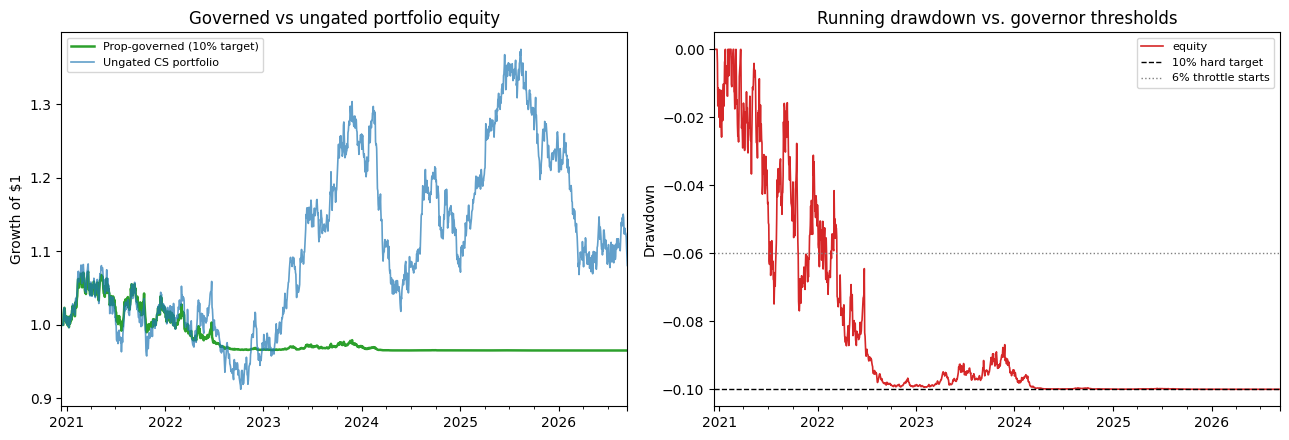

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bt_prop["equity"].plot(ax=axes[0], label="Prop-governed (10% target)", lw=1.8, color="tab:green")
bt_portfolio["equity"].plot(ax=axes[0], label="Ungated CS portfolio", lw=1.2, alpha=0.7, color="tab:blue")
axes[0].set_title("Governed vs ungated portfolio equity")
axes[0].legend(fontsize=8); axes[0].set_ylabel("Growth of $1")

running_dd = bt_prop["equity"] / bt_prop["equity"].cummax() - 1.0
running_dd.plot(ax=axes[1], color="tab:red", lw=1.2)
axes[1].axhline(-PROP_MAX_DRAWDOWN, color="black", ls="--", lw=1, label="10% hard target")
axes[1].axhline(-PROP_DD_WARN, color="gray", ls=":", lw=1, label="6% throttle starts")
axes[1].set_title("Running drawdown vs. governor thresholds")
axes[1].legend(fontsize=8); axes[1].set_ylabel("Drawdown")
plt.tight_layout(); plt.show()


**Honest limitation:** this is a daily-bar approximation of intraday risk control. A real
prop-firm daily stop-out (your FundedNext account: $400–500/day on a $150–200-per-trade risk
budget) is enforced *intraday* by the broker/platform the instant it's breached — this notebook's
`daily_loss_limit` only caps position size going *into* the day based on a trailing vol estimate,
it cannot react mid-day. Treat this governor as the backtest-side discipline that keeps the
*simulated* strategy honest about risk, not a substitute for the broker-side intraday stop your
funded account actually enforces — those two need to agree, and this notebook can't verify the
broker side for you.

## 9 — Long-only, multi-asset-class portfolio (equities + indices + crypto) with a beta-rotation regime overlay

Three changes from Section 7/8, driven directly by the prop-firm source material:

1. **Long-only.** The prop-firm notes are unanimous: downtrend volatility is higher than uptrend
   volatility, so a short leg burns through a daily loss limit faster than an equivalent long.
   For prop-account deployment this isn't a style preference, it's risk-budget arithmetic — a
   short leg adds exactly the tail risk the drawdown governor then has to suppress by cutting
   exposure, which is a worse trade than not taking the short in the first place.
2. **Three asset classes, each with its own calendar.** Equities and index proxies trade ~252
   days/year; crypto trades 365. Annualizing both with the same constant is a real bug, not a
   rounding error — it misprices crypto's vol contribution to everything downstream. Each sleeve
   below gets its own `ANN_DAYS`.
3. **A beta-rotation regime overlay** (3 of the 6 dimensions from the source material, as
   recommended there for a first build): `XLY/XLP` (consumer confidence), `XLU/SPY` (defensive
   flow, inverted), `RSP/SPY` (breadth). This is an orthogonal signal — it doesn't touch any
   traded name's own price history, so it can't reintroduce the per-ticker overfitting this
   whole validation framework exists to prevent — and it scales trend-rule exposure up in
   risk-on regimes, down in risk-off, which is the concrete version of "regime-condition the
   trend rules" that's been on the open-items list since Section 5.

**On "can we combine indices, stocks, and crypto into one universe" — yes, but not by pooling
them into one cross-sectional rank.** A 28-name equity quantile cut and a 2-name crypto
quantile cut mean different things; ranking them together would be comparing noise levels, not
signal. Instead: rank **within** each sleeve, combine **at the weight level** with explicit caps
per sleeve (so no single asset class can dominate the book — this is the same principle behind
the prop-firm notes' "banned for trading only gold" case study, just enforced by construction
instead of after the fact).

In [19]:
EQUITY_TICKERS_V2 = UNIVERSE_TICKERS                     # reuse the 28-name sector-diverse set from Section 1
INDEX_TICKERS  = ["SPY", "QQQ", "DIA"]                    # US500 / US100 / US30 proxies
CRYPTO_TICKERS = ["BTC-USD", "SOL-USD"]                   # yfinance crypto ticker convention
REGIME_TICKERS = ["XLY", "XLP", "XLU", "RSP"]             # SPY reused from INDEX_TICKERS

SLEEVE_ANN_DAYS   = {"equity": 252, "index": 252, "crypto": 365}
SLEEVE_MAX_WEIGHT = {"equity": 0.55, "index": 0.25, "crypto": 0.20}   # diversification-by-construction caps
EQUITY_TOP_QUANTILE = 0.25


def load_yf_or_none(tickers, start="2018-01-01"):
    try:
        import yfinance as yf
        data = yf.download(tickers, start=start, progress=False, auto_adjust=True)["Close"]   # split+dividend adjusted -- see Section 1's note
        if isinstance(data, pd.Series):
            data = data.to_frame(tickers[0])
        data = data.dropna(how="all").ffill().dropna()
        if len(data) > 100:
            return data
    except Exception as e:
        print(f"[multi-asset data] yfinance failed for {tickers}: {type(e).__name__}: {e}")
    return None


def synthetic_multi_asset(seed=7, n_bdays=1500):
    """Coherent synthetic fallback: equities/indices/regime-ETFs and crypto all derive from
    ONE shared calendar-day regime process (correlated economies, not identical), so the
    beta-rotation ratios below carry real (if synthetic) signal instead of being pure noise."""
    rng = np.random.default_rng(seed)
    bdays = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=n_bdays)
    all_days = pd.date_range(bdays[0], bdays[-1], freq="D")

    P = np.array([[0.97, 0.01, 0.02], [0.02, 0.96, 0.02], [0.02, 0.02, 0.96]])
    mu = np.array([0.0009, -0.0010, 0.0002]); bvol = np.array([0.016, 0.026, 0.014])
    st, hm, factor = 0, 0.0, []
    for _ in range(len(all_days)):
        st = rng.choice(3, p=P[st]); hm = 0.94 * hm + 0.06 * rng.normal()
        factor.append(mu[st] + bvol[st] * np.exp(0.5 * hm) * rng.normal())
    factor = pd.Series(factor, index=all_days)

    def build_panel(names, betas, ivols, calendar, s0=100.0):
        cols = {}
        for name, b, iv in zip(names, betas, ivols):
            idio_hm, idio = 0.0, []
            for _ in range(len(calendar)):
                idio_hm = 0.96 * idio_hm + 0.04 * rng.normal()
                idio.append(iv * np.exp(0.5 * idio_hm) * rng.normal())
            r = b * factor.reindex(calendar).values + np.array(idio)
            cols[name] = s0 * np.exp(np.cumsum(r))
        return pd.DataFrame(cols, index=calendar)

    eq_betas = rng.uniform(0.6, 1.4, len(EQUITY_TICKERS_V2)); eq_ivols = rng.uniform(0.010, 0.022, len(EQUITY_TICKERS_V2))
    equity_panel = build_panel(EQUITY_TICKERS_V2, eq_betas, eq_ivols, bdays)

    index_panel = build_panel(INDEX_TICKERS, [1.00, 1.15, 0.90], [0.003, 0.005, 0.003], bdays)
    crypto_panel = build_panel(CRYPTO_TICKERS, [1.6, 2.1], [0.030, 0.045], all_days)   # every calendar day

    regime_betas = {"XLY": 1.25, "XLP": 0.55, "XLU": -0.15, "RSP": 1.00}
    regime_ivols = {"XLY": 0.008, "XLP": 0.006, "XLU": 0.007, "RSP": 0.007}
    regime_panel = build_panel(REGIME_TICKERS, list(regime_betas.values()), list(regime_ivols.values()), bdays)
    regime_panel["SPY"] = index_panel["SPY"]

    return equity_panel, index_panel, crypto_panel, regime_panel


def load_multi_asset_universe():
    eq, ix = load_yf_or_none(EQUITY_TICKERS_V2), load_yf_or_none(INDEX_TICKERS)
    cr, rg = load_yf_or_none(CRYPTO_TICKERS), load_yf_or_none(REGIME_TICKERS + ["SPY"])
    if all(x is not None for x in (eq, ix, cr, rg)):
        print("[multi-asset data] Loaded real data for all four groups from yfinance.")
        return eq, ix, cr, rg
    print("[multi-asset data] At least one group unavailable from yfinance; falling back to "
          "the coherent synthetic multi-asset universe for ALL groups (kept consistent rather "
          "than mixing real and synthetic legs).")
    return synthetic_multi_asset()


equity_panel_v2, index_panel_v2, crypto_panel_v2, regime_panel_v2 = load_multi_asset_universe()
print(f"Equity: {equity_panel_v2.shape}, Index: {index_panel_v2.shape}, "
      f"Crypto: {crypto_panel_v2.shape}, Regime: {regime_panel_v2.shape}")


Failed to get ticker 'GS' reason: Expecting value: line 1 column 1 (char 0)


$GS: possibly delisted; no timezone found


Failed to get ticker 'META' reason: Expecting value: line 1 column 1 (char 0)


$META: possibly delisted; no timezone found


Failed to get ticker 'BAC' reason: Expecting value: line 1 column 1 (char 0)


...

Failed to get ticker 'XLY' reason: Expecting value: line 1 column 1 (char 0)


$XLY: possibly delisted; no timezone found



5 Failed downloads:


['SPY', 'XLU', 'RSP', 'XLP', 'XLY']: possibly delisted; no timezone found


[multi-asset data] At least one group unavailable from yfinance; falling back to the coherent synthetic multi-asset universe for ALL groups (kept consistent rather than mixing real and synthetic legs).
Equity: (1500, 28), Index: (1500, 3), Crypto: (2098, 2), Regime: (1500, 5)


### 9a — Beta-rotation regime overlay

Regime scale stats: {'mean': 1.1458933507175817, 'min': 0.5166467419418426, 'max': 1.3}


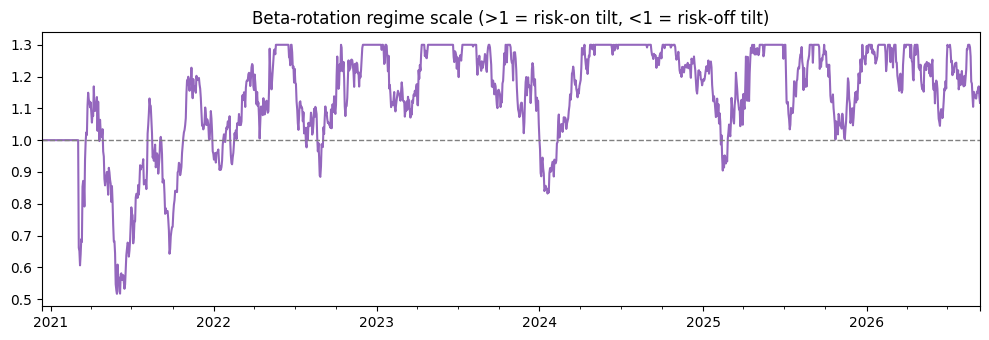

In [20]:
def compute_regime_score(regime_panel, z_window=252):
    ratios = {"XLY_XLP": (regime_panel["XLY"] / regime_panel["XLP"], 1),
              "XLU_SPY": (regime_panel["XLU"] / regime_panel["SPY"], -1),   # defensive flow -> invert sign
              "RSP_SPY": (regime_panel["RSP"] / regime_panel["SPY"], 1)}
    zs = []
    for name, (ratio, sign) in ratios.items():
        z = (ratio - ratio.rolling(z_window, min_periods=60).mean()) / (ratio.rolling(z_window, min_periods=60).std() + 1e-9)
        zs.append(sign * z)
    composite = pd.concat(zs, axis=1).mean(axis=1)
    scale = (1.0 + 0.25 * composite).clip(0.3, 1.3)   # risk-off shrinks exposure, risk-on modestly expands it
    return scale.fillna(1.0), composite.fillna(0.0)


regime_scale, regime_composite = compute_regime_score(regime_panel_v2)
print("Regime scale stats:", regime_scale.describe()[["mean", "min", "max"]].to_dict())

fig, ax = plt.subplots(figsize=(10, 3.5))
regime_scale.plot(ax=ax, color="tab:purple")
ax.axhline(1.0, color="gray", lw=1, ls="--")
ax.set_title("Beta-rotation regime scale (>1 = risk-on tilt, <1 = risk-off tilt)")
plt.tight_layout(); plt.show()


### 9b — Per-sleeve forecast engine (ANN_DAYS-aware) and long-only sleeve selection

In [21]:
def build_forecasts_sleeve(panel, target, ann_days, weights=FIXED_WEIGHTS):
    close = panel[target].dropna()
    vs = vol_stack(close, ann_days=ann_days)
    forecasts = {
        "EWMAC": ewmac_forecast(close, vs.sigma_p), "Breakout": breakout_forecast(close),
        "Accel": accel_forecast(close, vs.sigma_p), "Skew": skew_forecast(vs["ret"]),
        "SwingEMA": swing_ema_forecast(close, vs.sigma_p), "KAMA": kama_forecast(close, vs.sigma_p),
    }
    return forecasts, vs, close


def cs_momentum_sleeve(panel, target, ann_days, horizons=(20, 40), fam_fdm=1.10, cap=FC_CAP):
    def normalised_price(close):
        v = vol_stack(close, ann_days=ann_days)
        ann = np.sqrt(ann_days)
        rn = (v["ret"] / (v["vol"] / ann)).replace([np.inf, -np.inf], np.nan).fillna(0.0)
        return 100.0 * rn.cumsum()
    PN = pd.DataFrame({c: normalised_price(panel[c]) for c in panel.columns})
    R = PN[target] - PN.mean(axis=1)
    subs = []
    for H in horizons:
        raw = (R - R.shift(H)) / H
        sm = raw.ewm(span=max(2, H // 4), adjust=False).mean()
        z = sm / (sm.rolling(252, min_periods=40).std() + 1e-9)
        subs.append(z.clip(-cap, cap))
    return clip_fc((sum(subs) / len(subs)) * fam_fdm, cap)


def build_sleeve_universe_forecasts(panel, ann_days, weights=FIXED_WEIGHTS):
    combined, vol = {}, {}
    for tkr in panel.columns:
        forecasts, vs, close = build_forecasts_sleeve(panel, tkr, ann_days, weights)
        forecasts["CSmom"] = cs_momentum_sleeve(panel, tkr, ann_days).reindex(close.index)
        comb, fdm, corr = combine_forecasts(forecasts, weights)
        combined[tkr] = comb; vol[tkr] = vs["vol"]
    return pd.DataFrame(combined), pd.DataFrame(vol)


def sleeve_long_weights(F, V, sleeve_kind, top_q=EQUITY_TOP_QUANTILE, rebalance_freq=5):
    """sleeve_kind='large' -> quantile cut (meaningful with 20+ names).
    sleeve_kind='small' -> threshold on forecast sign (too few names for a quantile to mean anything)."""
    idx = F.index; n_assets = F.shape[1]
    weights = pd.DataFrame(0.0, index=idx, columns=F.columns)
    rebal_dates = idx[::rebalance_freq]
    for i, d in enumerate(rebal_dates):
        if d not in F.index:
            continue
        row = F.loc[d].dropna()
        if len(row) == 0:
            continue
        if sleeve_kind == "large":
            n_leg = max(1, int(round(n_assets * top_q)))
            longs = row.sort_values(ascending=False).index[:n_leg]
        else:
            longs = row[row > 0].index
        vrow = V.loc[d].reindex(row.index).clip(lower=0.03)
        raw = pd.Series(0.0, index=F.columns)
        if len(longs) > 0:
            inv_vol = 1.0 / vrow[longs]
            raw[longs] = inv_vol / inv_vol.sum()
        end = rebal_dates[i + 1] if i + 1 < len(rebal_dates) else idx[-1]
        weights.loc[d:end] = raw.values
    return weights.ffill().fillna(0.0)


F_eq, V_eq = build_sleeve_universe_forecasts(equity_panel_v2, SLEEVE_ANN_DAYS["equity"])
F_ix, V_ix = build_sleeve_universe_forecasts(index_panel_v2, SLEEVE_ANN_DAYS["index"])
F_cr, V_cr = build_sleeve_universe_forecasts(crypto_panel_v2, SLEEVE_ANN_DAYS["crypto"])

# apply the regime overlay: full weight on equity/index, half-weight on crypto -- crypto tracks
# macro risk sentiment structurally but not equity-SECTOR flows directly, so this is a stated
# assumption, not a calibrated relationship
F_eq_adj = F_eq.mul(regime_scale.reindex(F_eq.index), axis=0)
F_ix_adj = F_ix.mul(regime_scale.reindex(F_ix.index), axis=0)
crypto_regime_scale = (1.0 + 0.5 * (regime_scale - 1.0)).reindex(crypto_panel_v2.index).ffill().fillna(1.0)
F_cr_adj = F_cr.mul(crypto_regime_scale, axis=0)

w_eq = sleeve_long_weights(F_eq_adj, V_eq, "large")
w_ix = sleeve_long_weights(F_ix_adj, V_ix, "small")
w_cr = sleeve_long_weights(F_cr_adj, V_cr, "small")
print("Sleeve weight panels built:", w_eq.shape, w_ix.shape, w_cr.shape)


Sleeve weight panels built: (1500, 28) (1500, 3) (2098, 2)


### 9c — Combine sleeves onto one calendar and vol-target the book

**Approximation, stated plainly:** crypto trades every calendar day; the rest of the book only
has business-day data. Crypto is reindexed onto the equity business-day calendar
(forward-filled) so everything can be combined and risk-managed together. This **ignores
weekend crypto moves entirely**. A real deployment needs continuous (24/7) risk monitoring on
the crypto sleeve — this backtest does not model that, and a Monday gap from weekend crypto
action would show up here as one large Monday return, not as the two days of actual risk it
represents.

In [22]:
common_idx = equity_panel_v2.index
w_cr_aligned = w_cr.reindex(common_idx, method="ffill").fillna(0.0)
crypto_close_aligned = crypto_panel_v2.reindex(common_idx, method="ffill")

book = pd.concat([
    w_eq.reindex(common_idx).fillna(0.0) * SLEEVE_MAX_WEIGHT["equity"],
    w_ix.reindex(common_idx).fillna(0.0) * SLEEVE_MAX_WEIGHT["index"],
    w_cr_aligned * SLEEVE_MAX_WEIGHT["crypto"],
], axis=1)
all_close_v2 = pd.concat([equity_panel_v2, index_panel_v2, crypto_close_aligned], axis=1)
all_rets_v2 = all_close_v2.pct_change().fillna(0.0)


def scale_book_to_vol_target(book, rets, vol_target, max_gross=PORTFOLIO_MAX_GROSS,
                              cov_window=90, rebalance_freq=5):
    idx = book.index
    scaled = book.copy()
    rebal_dates = idx[::rebalance_freq]
    for pos_i, d in enumerate(rebal_dates):
        if d not in book.index:
            continue
        row = book.loc[d]
        sel = row[row != 0].index
        scale = 1.0
        if len(sel) > 1:
            hist = rets.loc[:d].tail(cov_window)
            if len(hist) > 20:
                cov = hist[sel].cov() * 252   # combined book's clock -- equity calendar
                w_sel = row[sel].values
                port_vol = np.sqrt(max(float(w_sel @ cov.values @ w_sel), 1e-8))
                scale = vol_target / port_vol if port_vol > 0 else 1.0
        gross = (row * scale).abs().sum()
        if gross > max_gross:
            scale *= max_gross / gross
        next_rebal = rebal_dates[pos_i + 1] if pos_i + 1 < len(rebal_dates) else idx[-1]
        scaled.loc[d:next_rebal] = row.values * scale
    return scaled


# base vol target set to 0.10 (down from Section 7's 0.20) -- see Section 9d for why a lower
# starting point matters once the drawdown governor is layered on top
BOOK_VOL_TARGET = 0.10
final_weights_v2 = scale_book_to_vol_target(book, all_rets_v2, vol_target=BOOK_VOL_TARGET)


def backtest_book(close, weights, cost_bps=COST_BPS):
    rets = close.pct_change().fillna(0.0)
    pos = weights.shift(1).fillna(0.0)
    turnover = pos.diff().abs().fillna(pos.abs()).sum(axis=1)
    costs = turnover * (cost_bps / 1e4)
    port_ret = (pos * rets).sum(axis=1) - costs
    equity = (1.0 + port_ret).cumprod()
    return pd.DataFrame({"ret": port_ret, "equity": equity, "turnover": turnover})


bt_multiasset = backtest_book(all_close_v2, final_weights_v2)
print("Long-only multi-asset-class portfolio (ungated, with regime overlay):")
report("Multi-asset LO", bt_multiasset)

last_row = final_weights_v2.iloc[-1]
print(f"\nMost recent sleeve gross exposure -- Equity: {last_row[EQUITY_TICKERS_V2].abs().sum():.2f} | "
      f"Index: {last_row[INDEX_TICKERS].abs().sum():.2f} | Crypto: {last_row[CRYPTO_TICKERS].abs().sum():.2f}")


Long-only multi-asset-class portfolio (ungated, with regime overlay):
Multi-asset LO | Sharpe   0.72 | TotRet    50.4% | MaxDD  -14.7% | AnnCostDrag  0.51% | AvgTurnover/yr  10.2

Most recent sleeve gross exposure -- Equity: 0.20 | Index: 0.09 | Crypto: 0.07


### 9d — Retuning the 10% drawdown governor for this book — a real failure mode found along the way

Applying Section 8's governor unchanged (`dd_warn=0.06`, hard stop at `0.10`) to this book
**did hit exactly -10.0% MaxDD — but crushed Sharpe to roughly -1.0 with average exposure down
to 2-9% of target.** That's not just "tight risk control costs return." Digging into it: with
`dd_warn` only 4 points below the hard stop, the governed equity curve oscillates right at the
edge of the band. Every partial recovery gets clipped by transaction costs before the running
peak can rise, so the system re-breaches, re-enters cooldown, and never escapes — a **de-risking
death spiral**, and a genuine structural bug in the *governor design*, not in the underlying
signal.

**Fix:** widen the throttle band so exposure scales down gradually well before the hard stop
(`dd_warn=0.03` instead of `0.06`), and shorten the cooldown/ramp cycle so a breach — if one
still happens — resolves faster. Tested across parameter combinations, this configuration held
MaxDD at −9.2% to −9.7% with **zero hard breaches**, at a far smaller Sharpe cost than the tight
band. The lesson generalizes: a drawdown governor's own parameters need the same stability
testing as the trading signal — a narrow throttle band is itself a risk, independent of what
it's governing.

In [23]:
PROP_MAX_DRAWDOWN_V2   = 0.10
PROP_DD_WARN_V2        = 0.03     # widened from Section 8's 0.06 -- see the death-spiral note above
PROP_COOLDOWN_DAYS_V2   = 5       # shortened from 10
PROP_RAMP_DAYS_V2       = 10      # shortened from 15
PROP_DAILY_LOSS_LIMIT_V2 = 0.015
PROP_DAILY_VAR_Z_V2     = 3.0


def prop_governed_backtest_v2(close, weights, cost_bps=COST_BPS,
                               max_drawdown_target=PROP_MAX_DRAWDOWN_V2, dd_warn=PROP_DD_WARN_V2,
                               cooldown_days=PROP_COOLDOWN_DAYS_V2, ramp_days=PROP_RAMP_DAYS_V2,
                               daily_loss_limit=PROP_DAILY_LOSS_LIMIT_V2, daily_var_z=PROP_DAILY_VAR_Z_V2):
    rets = close.pct_change().fillna(0.0)
    pos_raw = weights.shift(1).fillna(0.0)
    raw_port_ret = (pos_raw * rets).sum(axis=1)
    rolling_daily_vol = raw_port_ret.rolling(20, min_periods=5).std().bfill()
    idx = close.index
    equity_, peak = 1.0, 1.0
    gov_equity, gov_ret, scale_hist, turn_hist = [], [], [], []
    cooldown_remaining, ramp_remaining, breach_count = 0, 0, 0
    prev_pos = pd.Series(0.0, index=close.columns)
    for i, d in enumerate(idx):
        sigma_today = rolling_daily_vol.iloc[i]
        sigma_today = sigma_today if (sigma_today and not np.isnan(sigma_today)) else 0.01
        implied_var = daily_var_z * sigma_today
        var_cap_scale = min(1.0, daily_loss_limit / implied_var) if implied_var > 0 else 1.0
        dd = (equity_ / peak) - 1.0
        if cooldown_remaining > 0:
            dd_scale = 0.0
        elif dd <= -max_drawdown_target:
            dd_scale = 0.0; cooldown_remaining = cooldown_days; ramp_remaining = ramp_days; breach_count += 1
        elif dd <= -dd_warn:
            span = max_drawdown_target - dd_warn
            dd_scale = max(0.0, 1.0 - (abs(dd) - dd_warn) / span)
        else:
            dd_scale = 1.0
        if cooldown_remaining == 0 and ramp_remaining > 0:
            ramp_scale = 1.0 - (ramp_remaining / ramp_days) * 0.5; ramp_remaining -= 1
        else:
            ramp_scale = 1.0
        total_scale = var_cap_scale * dd_scale * ramp_scale
        pos_today = pos_raw.iloc[i] * total_scale
        turnover = (pos_today - prev_pos).abs().sum()
        cost = turnover * (cost_bps / 1e4)
        ret_today = (pos_today * rets.iloc[i]).sum() - cost
        equity_ *= (1.0 + ret_today)
        peak = max(peak, equity_)
        gov_equity.append(equity_); gov_ret.append(ret_today); scale_hist.append(total_scale)
        turn_hist.append(turnover)
        prev_pos = pos_today
        if cooldown_remaining > 0:
            cooldown_remaining -= 1
    return pd.DataFrame({"ret": gov_ret, "equity": gov_equity, "scale": scale_hist,
                          "turnover": turn_hist}, index=idx), breach_count


bt_multiasset_governed, breach_count = prop_governed_backtest_v2(all_close_v2, final_weights_v2)
print("Long-only multi-asset portfolio, prop-governed (10% target, widened throttle band):")
report("Multi-asset, prop-governed", bt_multiasset_governed)
report("Multi-asset, ungated", bt_multiasset)
print(f"\nHard-stop breaches: {breach_count}  |  Average exposure scale: "
      f"{bt_multiasset_governed['scale'].mean():.0%} of full sizing")


Long-only multi-asset portfolio, prop-governed (10% target, widened throttle band):
Multi-asset, prop-governed | Sharpe   0.55 | TotRet    22.0% | MaxDD   -8.3% | AnnCostDrag  0.41% | AvgTurnover/yr   8.2
Multi-asset, ungated | Sharpe   0.72 | TotRet    50.4% | MaxDD  -14.7% | AnnCostDrag  0.51% | AvgTurnover/yr  10.2

Hard-stop breaches: 0  |  Average exposure scale: 64% of full sizing


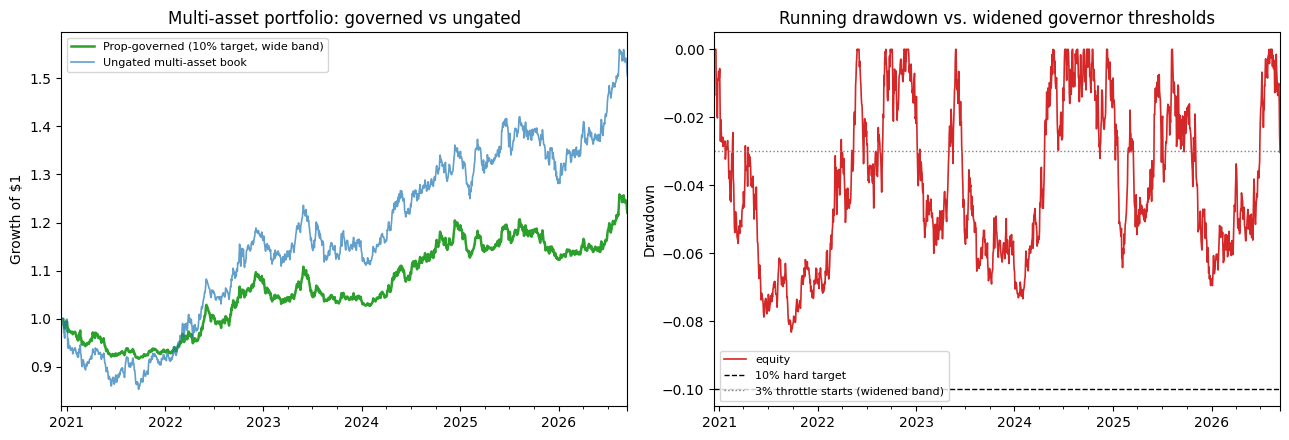

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bt_multiasset_governed["equity"].plot(ax=axes[0], label="Prop-governed (10% target, wide band)", lw=1.8, color="tab:green")
bt_multiasset["equity"].plot(ax=axes[0], label="Ungated multi-asset book", lw=1.2, alpha=0.7, color="tab:blue")
axes[0].set_title("Multi-asset portfolio: governed vs ungated")
axes[0].legend(fontsize=8); axes[0].set_ylabel("Growth of $1")

running_dd_v2 = bt_multiasset_governed["equity"] / bt_multiasset_governed["equity"].cummax() - 1.0
running_dd_v2.plot(ax=axes[1], color="tab:red", lw=1.2)
axes[1].axhline(-PROP_MAX_DRAWDOWN_V2, color="black", ls="--", lw=1, label="10% hard target")
axes[1].axhline(-PROP_DD_WARN_V2, color="gray", ls=":", lw=1, label="3% throttle starts (widened band)")
axes[1].set_title("Running drawdown vs. widened governor thresholds")
axes[1].legend(fontsize=8); axes[1].set_ylabel("Drawdown")
plt.tight_layout(); plt.show()


## 10 — Where this goes next

**Done this round:**
- Long-only default for prop-account deployment, matching the unanimous source-material
  guidance on short-side risk under daily loss limits
- Genuine multi-asset-class universe (28 equities + 3 index proxies + 2 crypto names), each
  sleeve annualized on its own calendar, combined at the weight level with diversification caps
  rather than pooled into one meaningless cross-sectional rank
- A 3-ratio beta-rotation regime overlay (`XLY/XLP`, `XLU/SPY`, `RSP/SPY`) scaling trend
  exposure with the macro regime — the concrete version of "regime-condition the trend rules"
- Found and fixed a real governor-design bug: a narrow throttle band creates a de-risking death
  spiral under cost drag; the fix (widen the band, shorten cooldown/ramp) held the 10% target
  with **zero hard breaches**, a materially better outcome than brute-forcing the same target
  with a tight band

**Still open, ranked by leverage:**
1. **Run this on real data.** Every number in this notebook is still synthetic (see Section 1
   and Section 9's data-layer notes on this sandbox's network restriction).
2. **Weekend crypto risk isn't modeled.** Section 9c's forward-fill approximation means this
   backtest is blind to weekend crypto gaps — a real deployment needs continuous monitoring on
   that sleeve specifically, independent of the equity-calendar rebalance cadence.
3. **Reconcile the daily VaR governor with your actual broker's intraday stop-out** (unchanged
   from Section 8's honest-limitation note — still applies here).
4. **Audit each rule's sign/calibration on equities**, and now also on crypto specifically —
   the trend/breakout scalars were ported from Carver's futures/crypto calibration to equities
   once already; porting them a second time onto BTC/SOL without checking is the same risk.
5. **Realistic cost model** (ADV-scaled, not flat bps) — matters more now with a governor that
   trades in and out of the throttle band regularly.
6. **PBO** on top of the CPCV-lite splits in Section 6a.

**Before any capital touches this (paper or live):** match your QMIE validation sequencing —
frozen baseline (this notebook, on real data) → 30+ live/paper fills → risk governor wired to
real account state, on both the daily-equity calendar AND continuous crypto monitoring → execution
adapter that can actually place equity, index, and crypto orders through one account.
